In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('master_table.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Id                  940 non-null    int64
 1   ActivityDate        940 non-null    str  
 2   TotalSteps          940 non-null    int64
 3   Calories            940 non-null    int64
 4   VeryActiveMinutes   940 non-null    int64
 5   SedentaryMinutes    940 non-null    int64
 6   Key                 940 non-null    str  
 7   TotalMinutesAsleep  940 non-null    int64
 8   TotalTimeInBed      940 non-null    int64
dtypes: int64(7), str(2)
memory usage: 66.2 KB


In [4]:
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  940 non-null    int64         
 1   ActivityDate        940 non-null    datetime64[us]
 2   TotalSteps          940 non-null    int64         
 3   Calories            940 non-null    int64         
 4   VeryActiveMinutes   940 non-null    int64         
 5   SedentaryMinutes    940 non-null    int64         
 6   Key                 940 non-null    str           
 7   TotalMinutesAsleep  940 non-null    int64         
 8   TotalTimeInBed      940 non-null    int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 66.2 KB


In [6]:
df.describe()

,Id,ActivityDate,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes,TotalMinutesAsleep,TotalTimeInBed
count,9.400000e+02,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,2016-05-17 10:08:10.212766,7637.910638,2303.609574,21.164894,991.210638,116.358511,127.179787
min,1.503960e+09,2016-01-05 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,2016-04-16 00:00:00,3789.750000,1828.500000,0.000000,729.750000,0.000000,0.000000
50%,4.445115e+09,2016-04-23 00:00:00,7405.500000,2134.000000,4.000000,1057.500000,0.000000,0.000000
75%,6.962181e+09,2016-05-05 00:00:00,10727.000000,2793.250000,32.000000,1229.500000,278.500000,339.750000
max,8.877689e+09,2016-12-05 00:00:00,36019.000000,4900.000000,210.000000,1440.000000,775.000000,961.000000
std,2.424805e+09,NaN,5087.150742,718.166862,32.844803,301.267437,197.309459,215.179026


In [7]:
(df['TotalMinutesAsleep'] == 0).sum()

np.int64(677)

In [8]:
df[df['TotalMinutesAsleep'] > 0]['TotalMinutesAsleep'].mean()

np.float64(415.88212927756655)

In [10]:
leep_df = df[df['TotalMinutesAsleep'] > 0]

In [13]:
sleep_df = df[df['TotalMinutesAsleep'] > 0]

In [14]:
sleep_df.shape

(263, 9)

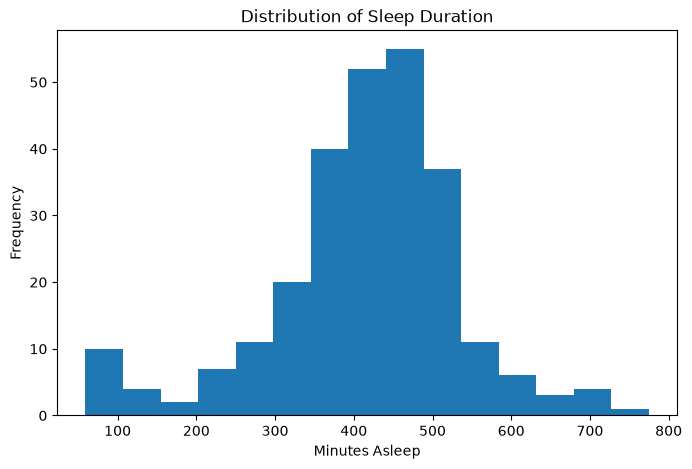

In [15]:
plt.figure(figsize=(8,5))
plt.hist(sleep_df['TotalMinutesAsleep'], bins=15)
plt.title('Distribution of Sleep Duration')
plt.xlabel('Minutes Asleep')
plt.ylabel('Frequency')
plt.show()

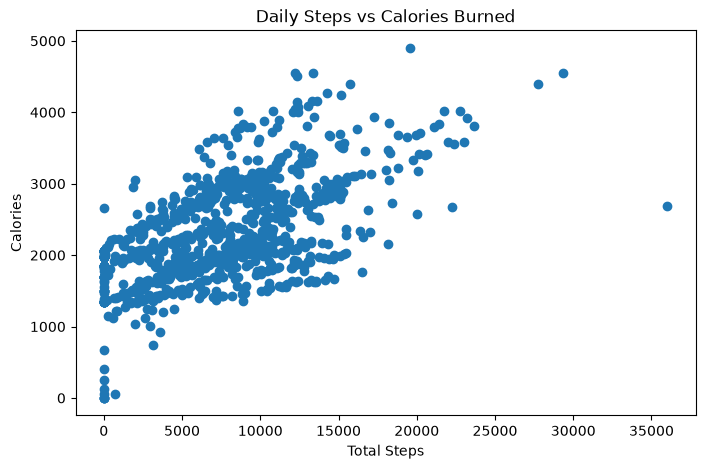

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df['TotalSteps'], df['Calories'])
plt.title('Daily Steps vs Calories Burned')
plt.xlabel('Total Steps')
plt.ylabel('Calories')
plt.show()

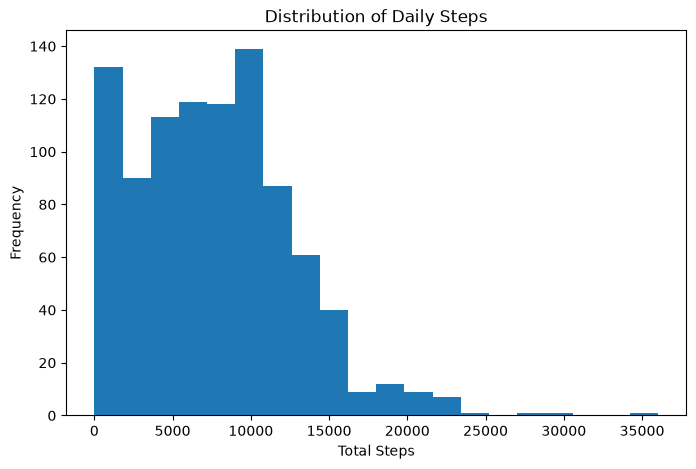

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['TotalSteps'], bins=20)
plt.title('Distribution of Daily Steps')
plt.xlabel('Total Steps')
plt.ylabel('Frequency')
plt.show()

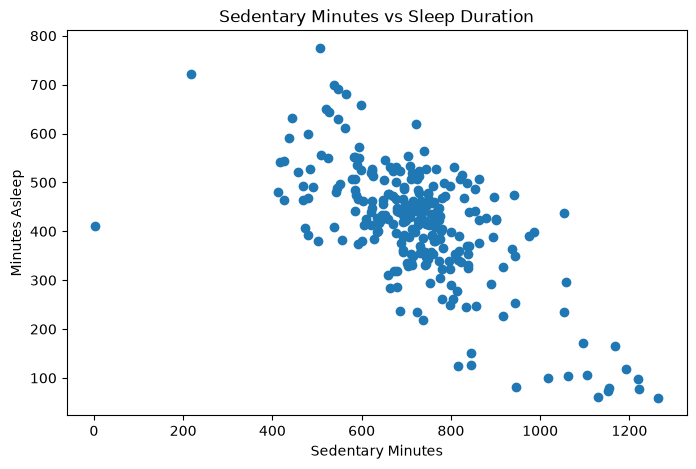

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(
    sleep_df['SedentaryMinutes'],
    sleep_df['TotalMinutesAsleep']
)
plt.title('Sedentary Minutes vs Sleep Duration')
plt.xlabel('Sedentary Minutes')
plt.ylabel('Minutes Asleep')
plt.show()

In [18]:
correlation = df[['TotalSteps',
                  'Calories',
                  'VeryActiveMinutes',
                  'SedentaryMinutes',
                  'TotalMinutesAsleep',
                  'TotalTimeInBed']].corr()

correlation

,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes,TotalMinutesAsleep,TotalTimeInBed
TotalSteps,1.000000,0.591568,0.667079,-0.327484,0.098682,0.101136
Calories,0.591568,1.000000,0.615838,-0.106973,0.092778,0.072956
VeryActiveMinutes,0.667079,0.615838,1.000000,-0.164671,0.078610,0.074417
SedentaryMinutes,-0.327484,-0.106973,-0.164671,1.000000,-0.581827,-0.584685
TotalMinutesAsleep,0.098682,0.092778,0.078610,-0.581827,1.000000,0.993687
TotalTimeInBed,0.101136,0.072956,0.074417,-0.584685,0.993687,1.000000


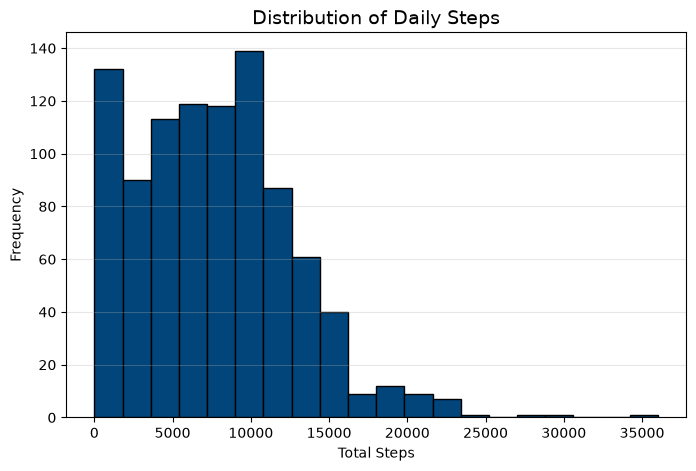

In [19]:
plt.figure(figsize=(8,5))
plt.hist(
    df['TotalSteps'],
    bins=20,
    color='#02457A',
    edgecolor='black'
)

plt.title('Distribution of Daily Steps', fontsize=14)
plt.xlabel('Total Steps')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

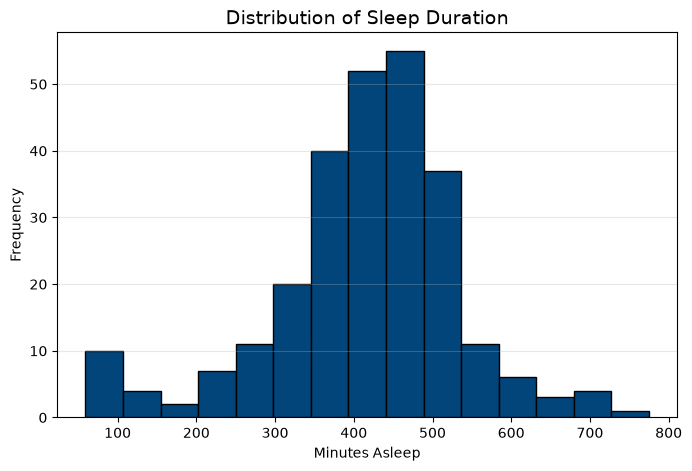

In [20]:
plt.figure(figsize=(8,5))
plt.hist(
    sleep_df['TotalMinutesAsleep'],
    bins=15,
    color='#02457A',
    edgecolor='black'
)

plt.title('Distribution of Sleep Duration', fontsize=14)
plt.xlabel('Minutes Asleep')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

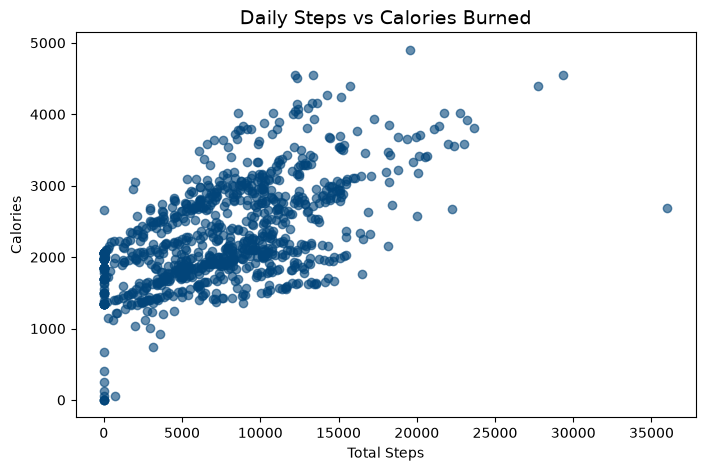

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['TotalSteps'],
    df['Calories'],
    color='#02457A',
    alpha=0.6
)

plt.title('Daily Steps vs Calories Burned', fontsize=14)
plt.xlabel('Total Steps')
plt.ylabel('Calories')

plt.show()

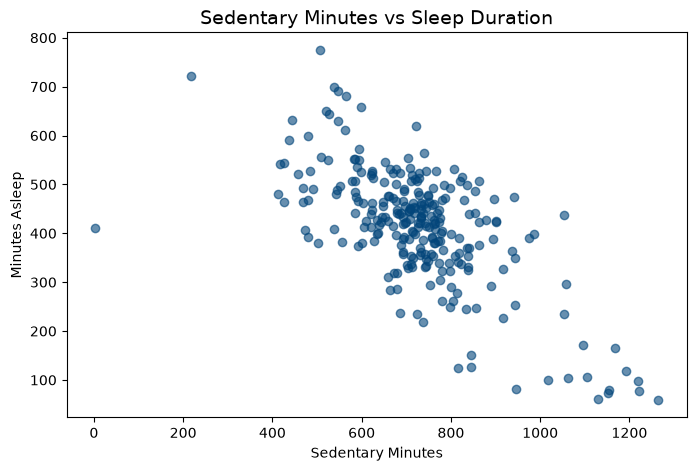

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(
    sleep_df['SedentaryMinutes'],
    sleep_df['TotalMinutesAsleep'],
    color='#02457A',
    alpha=0.6
)

plt.title('Sedentary Minutes vs Sleep Duration', fontsize=14)
plt.xlabel('Sedentary Minutes')
plt.ylabel('Minutes Asleep')

plt.show()

In [24]:
import seaborn as sns

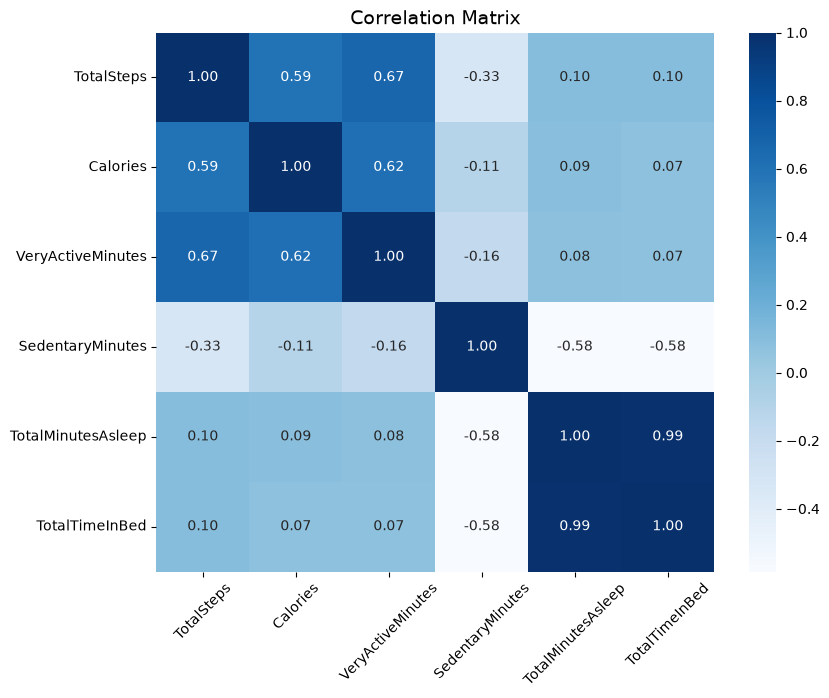

In [25]:
plt.figure(figsize=(9,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Correlation Matrix', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.savefig(
    'correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()